# §5 · Modifikationen des Black-Litterman-Modells
**Bachelorarbeit: Kritik des CAPM und Erweiterung durch das Black-Litterman-Modell**  
Lucas Posern · TU Dresden · 2026

> LaTeX: `Modifikation.tex`

| Abschnitt | Inhalt |
|---|---|
| §5.1 | Kovarianzschätzung: Sample vs. Ledoit-Wolf |
| §5.2 | Verteilungsannahme: Normal vs. Student-t |
| §5.3 | Risk Budgeting: RBMV-Framework |

Läuft vollständig offline, ohne Internetzugang.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath(''))
CORE = ROOT / 'core'
DATA = ROOT / 'data'
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))

from data_loader import IDZOREK_W_EQ  # Gleichgewichtsgewichte (Idzorek 2004)
from covariance import sample_cov, ledoit_wolf_cov
from views import ViewSet
from black_litterman import run_blm, implied_risk_aversion, implied_returns
from portfolio_metrics import performance_summary, cumulative_returns
from risk_budgeting import solve_rb, solve_rbmv, solve_mv, auto_params, risk_contributions, gini_index

plt.rcParams.update({
    'figure.dpi': 130, 'figure.figsize': (9, 4.5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'lines.linewidth': 1.8,
})
C = ['#1f4e79', '#c00000', '#538135', '#7030a0', '#833c00', '#005073']
from IPython.display import display
print('Setup abgeschlossen.')

Setup abgeschlossen.


In [2]:
# Konstanten
TICKERS = ["AGG", "BWX", "IWF", "IWD", "IWO", "IWN", "EFA", "EEM"]
LABELS  = {"AGG": "US Bonds", "BWX": "Intl Bonds", "IWF": "US Lg Growth",
           "IWD": "US Lg Value", "IWO": "US Sm Growth", "IWN": "US Sm Value",
           "EFA": "Intl Dev", "EEM": "Emg Mkts"}
SHORT   = {"AGG": "US Bonds", "BWX": "Intl Bonds", "IWF": "Lg Growth",
           "IWD": "Lg Value", "IWO": "Sm Growth", "IWN": "Sm Value",
           "EFA": "Intl Dev", "EEM": "Emg Mkts"}
# Gleichgewichtsgewichte: globales Marktportfolio (Idzorek et al.), Trainingsstart 2008
_eq_file = DATA / "eq_weights_train_start.csv"
if _eq_file.exists():
    _eq_df    = pd.read_csv(_eq_file, index_col=0)
    W_EQ_DICT = _eq_df["w_eq"].reindex(TICKERS).to_dict()
    print("w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.")
else:
    print("WARNUNG: eq_weights_train_start.csv nicht gefunden \u2192 Idzorek-Fallback")
    _W_EQ_RAW = {"AGG": 0.1934, "BWX": 0.2613, "IWF": 0.1209, "IWD": 0.1209,
                 "IWO": 0.0134, "IWN": 0.0134, "EFA": 0.2418, "EEM": 0.0349}
    _total    = sum(_W_EQ_RAW.values())
    W_EQ_DICT = {k: v / _total for k, v in _W_EQ_RAW.items()}
TAU       = 0.05

# Daten laden (offline, identisch mit 03_CAPM.ipynb und 04_BLM.ipynb)
_ret = pd.read_csv(DATA / "etf_returns_monthly.csv", index_col=0, parse_dates=True)
_ret.index = pd.to_datetime(_ret.index).to_period("M").to_timestamp("M")
returns_all = _ret.loc[:, TICKERS].dropna()

_rf = pd.read_csv(DATA / "rf_monthly.csv", index_col=0, parse_dates=True)
rf_all = _rf.iloc[:, 0] if isinstance(_rf, pd.DataFrame) else _rf
rf_all.index = pd.to_datetime(rf_all.index).to_period("M").to_timestamp("M")
rf_all = rf_all.reindex(returns_all.index).ffill()

_mkt = pd.read_csv(DATA / "spx_returns_monthly.csv", index_col=0, parse_dates=True)
mkt_all = _mkt.iloc[:, 0] if isinstance(_mkt, pd.DataFrame) else _mkt
mkt_all.index = pd.to_datetime(mkt_all.index).to_period("M").to_timestamp("M")
mkt_all = mkt_all.reindex(returns_all.index).ffill()

train_mask = (returns_all.index >= "2008-01-01") & (returns_all.index <= "2018-12-31")
test_mask  = (returns_all.index >= "2019-01-01") & (returns_all.index <= "2024-12-31")

returns_train = returns_all.loc[train_mask]
rf_train      = rf_all.loc[train_mask]
mkt_train     = mkt_all.loc[train_mask]
excess_train  = returns_train.sub(rf_train, axis=0)
returns_test  = returns_all.loc[test_mask]
rf_test       = rf_all.loc[test_mask]
assets        = list(returns_train.columns)

delta = implied_risk_aversion(mkt_train, annualize=True, frequency="M")
w_eq  = pd.Series(W_EQ_DICT).reindex(assets)
w_eq  = w_eq / w_eq.sum()

print(f"Train: {returns_train.index[0].date()} \u2013 {returns_train.index[-1].date()} ({len(returns_train)} Monate)")
print(f"Test:  {returns_test.index[0].date()} \u2013 {returns_test.index[-1].date()} ({len(returns_test)} Monate)")
print(f"delta = {delta:.4f}, tau = {TAU}")

w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.
Train: 2008-01-31 – 2018-12-31 (132 Monate)
Test:  2019-01-31 – 2024-12-31 (72 Monate)
delta = 2.4437, tau = 0.05


---
## §5.1 · Kovarianzschätzung: Sample vs. Ledoit-Wolf

In [3]:
# Kovarianzmatrizen berechnen
Sigma_sample = sample_cov(excess_train, annualize=True, frequency="M")
Sigma_lw     = ledoit_wolf_cov(excess_train, annualize=True, frequency="M")

kappa_sample = np.linalg.cond(Sigma_sample.values)
kappa_lw     = np.linalg.cond(Sigma_lw.values)
print(f"Konditionszahl Sample-Cov:      {kappa_sample:.1f}")
print(f"Konditionszahl Ledoit-Wolf-Cov: {kappa_lw:.1f}")
print(f"Reduktion: Faktor {kappa_sample/kappa_lw:.1f}")

# Views (Szenario A)
def make_views_lw(Sigma_used):
    vs = ViewSet(asset_names=assets)
    vs.add_relative(["IWF"], ["IWD"], expected_diff=0.03, confidence=0.50, label="US Growth > US Value (IWF>IWD): +3% p.a.")
    vs.add_relative(["EEM"], ["EFA"], expected_diff=0.04, confidence=0.50, label="Emerg. Mkt. > Intl. Dev. (EEM>EFA): +4% p.a.")
    vs.add_relative(["IWF"], ["AGG"], expected_diff=0.06, confidence=0.50, label="US Growth > US Bonds (IWF>AGG): +6% p.a.")
    P, Q, Omega = vs.build(Sigma=Sigma_used, tau=TAU, omega_method="idzorek")
    return run_blm(Sigma_used, w_eq, P, Q, Omega, delta=delta, tau=TAU)

res_sample = make_views_lw(Sigma_sample)
res_lw     = make_views_lw(Sigma_lw)
w_BL_sample = res_sample["w_BL"]
w_BL_lw     = res_lw["w_BL"]
pi_sample   = res_sample["pi"]
mu_BL_sample = res_sample["mu_BL"]
mu_BL_lw     = res_lw["mu_BL"]

print(f"\n{'Asset':20s}  {'w_eq':>7}  {'w_BL_Std':>9}  {'w_BL_LW':>8}")
for t in assets:
    print(f"  {LABELS[t]:20s}  {w_eq[t]*100:+.1f}%  {w_BL_sample[t]*100:+.1f}%  {w_BL_lw[t]*100:+.1f}%")

Konditionszahl Sample-Cov:      341.8
Konditionszahl Ledoit-Wolf-Cov: 108.0
Reduktion: Faktor 3.2

Asset                    w_eq   w_BL_Std   w_BL_LW
  US Bonds              +19.3%  +4.3%  +3.3%
  Intl Bonds            +26.1%  +24.9%  +24.9%
  US Lg Growth          +12.1%  +170.2%  +119.9%
  US Lg Value           +12.1%  -133.1%  -81.7%
  US Sm Growth          +1.3%  +1.3%  +1.3%
  US Sm Value           +1.3%  +1.3%  +1.3%
  Intl Dev              +24.2%  -29.3%  -25.6%
  Emg Mkts              +3.5%  +55.7%  +52.0%


In [4]:
# §5.1 Kennzahlen: alle im Text zitierten Werte
# Konditionszahlen bereits oben berechnet; hier: mu_s, alpha, Delta_pi, MV-Gewichte

import numpy as np

Sigma_s = Sigma_sample.values   # annualisiert
Sigma_L = Sigma_lw.values
n = Sigma_s.shape[0]

# Durchschnittliche Einzelvarianz (Shrinkage-Target-Skalar)
mu_s = np.trace(Sigma_s) / n
print(f"Durchschnittliche Varianz mu_s = {mu_s:.6f}  ({mu_s*100:.4f}% p.a.)")

# Shrinkage-Koeffizient alpha (LW-analytisch)
from sklearn.covariance import LedoitWolf
lw_fit = LedoitWolf().fit(excess_train.values)
alpha_lw = lw_fit.shrinkage_
print(f"Ledoit-Wolf Shrinkage alpha     = {alpha_lw:.4f}")

# Verschiebung Prior (Delta pi)
delta_pi = delta * (Sigma_L - Sigma_s) @ w_eq.values
print(f"\nPrior-Verschiebung Delta_pi (p.a.):")
for t, v in zip(assets, delta_pi * 100):
    print(f"  {t:4s}: {v:+.3f}%  (|Delta_pi| = {abs(v):.3f}%)")
max_shift = np.max(np.abs(delta_pi)) * 100
print(f"  Max |Delta_pi|: {max_shift:.3f}% p.a.")

# Unrestringierte MV-Gewichte (Tangentialportfolio) - zeigt Extremallokationen
mu_ann = excess_train.mean() * 12          # annualisierte Erwartungsrenditen
rf_ann = rf_train.mean() * 12
excess_mu = mu_ann.values - rf_ann

Sigma_inv_s = np.linalg.inv(Sigma_s)
Sigma_inv_L = np.linalg.inv(Sigma_L)

w_mv_sample = Sigma_inv_s @ excess_mu
w_mv_sample /= np.sum(w_mv_sample)          # Summe = 1
w_mv_lw     = Sigma_inv_L @ excess_mu
w_mv_lw    /= np.sum(w_mv_lw)

print(f"\nUnrestringierte MV-Tangentialgewichte (%):")
print(f"  {'Asset':4s}  {'Sample-Cov':>12}  {'Ledoit-Wolf':>12}")
for t, ws, wl in zip(assets, w_mv_sample*100, w_mv_lw*100):
    print(f"  {t:4s}  {ws:+12.1f}%  {wl:+12.1f}%")


Durchschnittliche Varianz mu_s = 0.028174  (2.8174% p.a.)
Ledoit-Wolf Shrinkage alpha     = 0.0406

Prior-Verschiebung Delta_pi (p.a.):
  AGG : +0.039%  (|Delta_pi| = 0.039%)
  BWX : -0.003%  (|Delta_pi| = 0.003%)
  IWF : -0.140%  (|Delta_pi| = 0.140%)
  IWD : -0.141%  (|Delta_pi| = 0.141%)
  IWO : -0.197%  (|Delta_pi| = 0.197%)
  IWN : -0.189%  (|Delta_pi| = 0.189%)
  EFA : -0.165%  (|Delta_pi| = 0.165%)
  EEM : -0.252%  (|Delta_pi| = 0.252%)
  Max |Delta_pi|: 0.252% p.a.

Unrestringierte MV-Tangentialgewichte (%):
  Asset    Sample-Cov   Ledoit-Wolf
  AGG          +80.4%         +66.3%
  BWX           +4.2%         +15.2%
  IWF          +76.3%         +68.8%
  IWD          -16.1%          +1.0%
  IWO          -17.1%          +0.7%
  IWN          +15.0%          +1.0%
  EFA          -33.2%         -37.3%
  EEM           -9.4%         -15.6%


BLM Sample: Shorts=2, Brutto-Exposure=4.20  ->  Long-Only fully invested
BLM LW    : Shorts=2, Brutto-Exposure=3.10  ->  Long-Only fully invested
Performance (Test Jan 2019 - Dez 2024):
                         Ann. Return  Ann. Volatility  Sharpe Ratio  \
Portfolio                                                             
CAPM Baseline                   3.85            12.16          0.32   
BLM (Sample-Cov)               17.78            24.39          0.73   
BLM (Sample, Long-Only)         8.37            14.82          0.56   
BLM (Ledoit-Wolf)              13.46            19.41          0.69   
BLM (LW, Long-Only)             8.96            15.26          0.59   

                         Max Drawdown  Total Return  
Portfolio                                            
CAPM Baseline                  -24.78         20.51  
BLM (Sample-Cov)               -51.30        142.62  
BLM (Sample, Long-Only)        -27.87         54.60  
BLM (Ledoit-Wolf)              -42.26        1

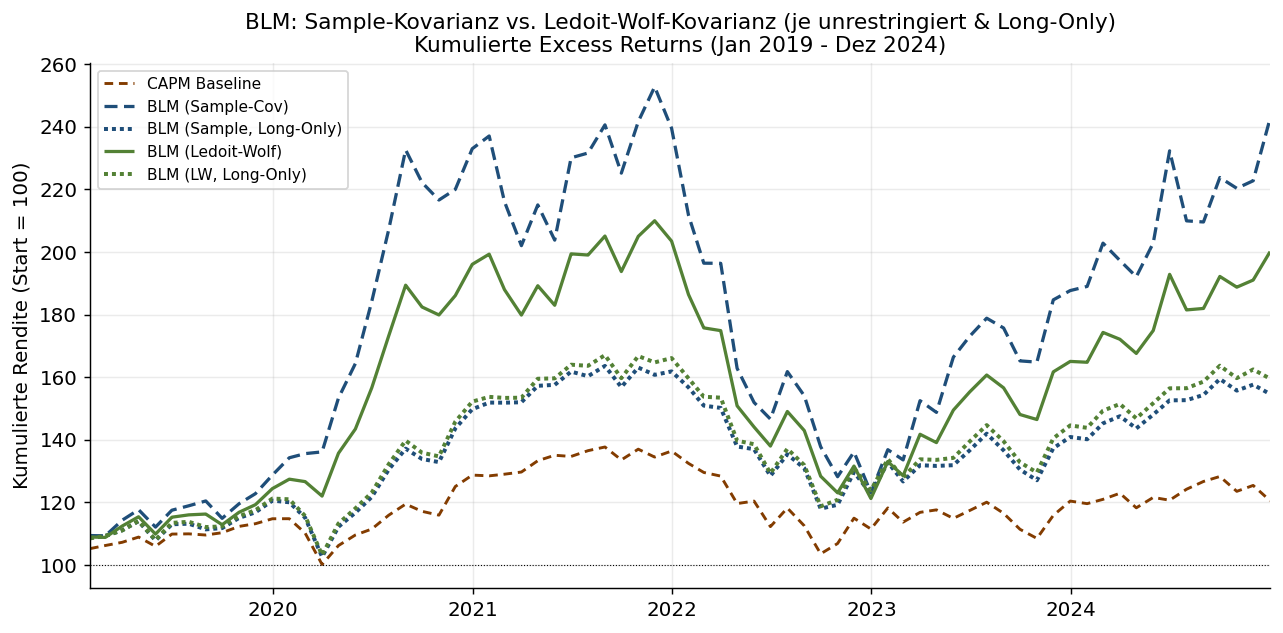

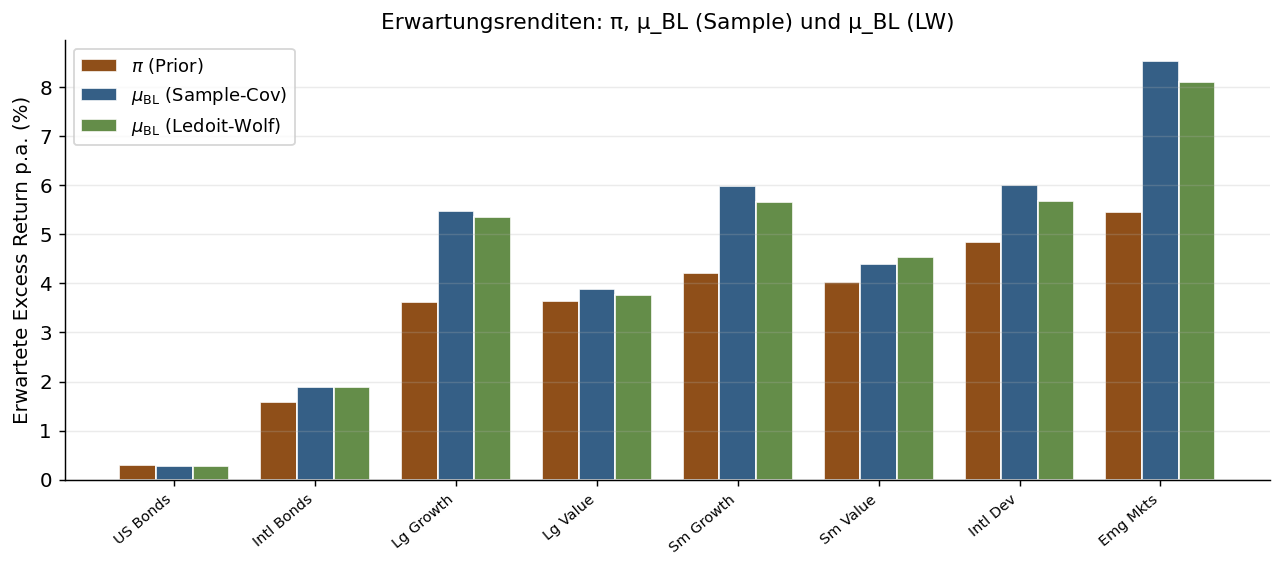

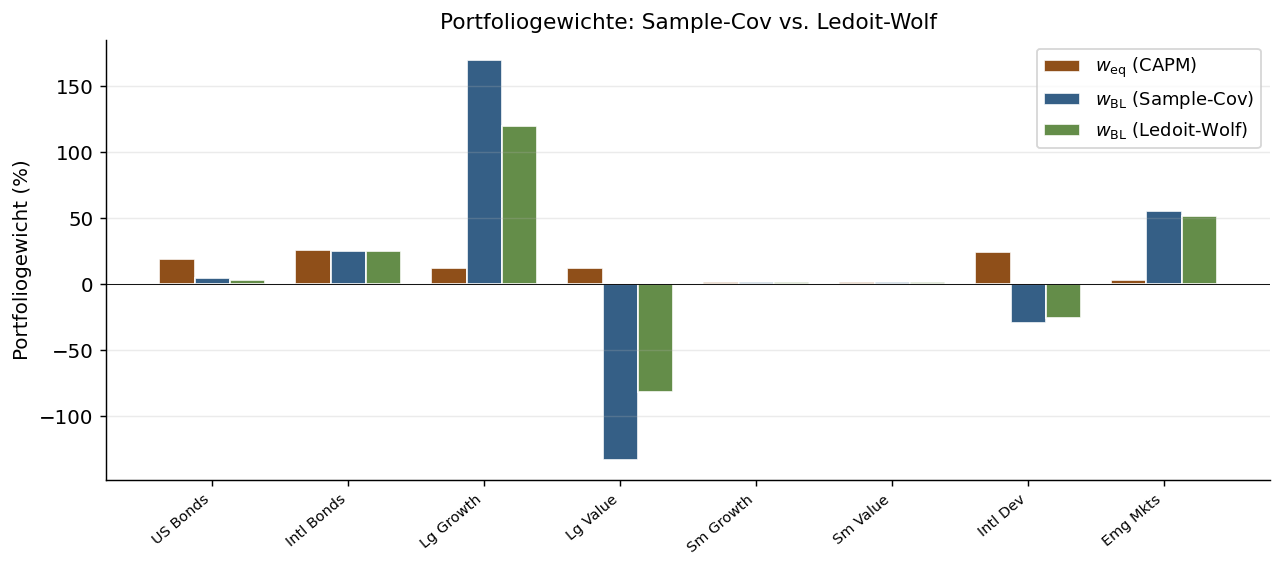

In [5]:
# Backtest
exc_test   = returns_test.sub(rf_test, axis=0)
ret_capm   = (exc_test * w_eq).sum(axis=1).rename("CAPM Baseline")
ret_bl_std = (exc_test * w_BL_sample).sum(axis=1).rename("BLM (Sample-Cov)")
ret_bl_lw  = (exc_test * w_BL_lw).sum(axis=1).rename("BLM (Ledoit-Wolf)")

# Long-Only-Pendants (echte QP, w≥0 & Σw=1; gleiche Zielfunktion auf μ_BL, Σ_post)
# Leerverkaufsverbot als implizite Regularisierung (Jagannathan & Ma 2003).
from optimize import mv_weights, constraint_diagnostics
w_BL_sample_lo = mv_weights(res_sample["mu_BL"], res_sample["Sigma_post"], delta, long_only=True)
w_BL_lw_lo     = mv_weights(res_lw["mu_BL"],     res_lw["Sigma_post"],     delta, long_only=True)
ret_bl_std_lo  = (exc_test * w_BL_sample_lo).sum(axis=1).rename("BLM (Sample, Long-Only)")
ret_bl_lw_lo   = (exc_test * w_BL_lw_lo).sum(axis=1).rename("BLM (LW, Long-Only)")

_d_s = constraint_diagnostics(w_BL_sample, w_BL_sample_lo)
_d_l = constraint_diagnostics(w_BL_lw,     w_BL_lw_lo)
print(f"BLM Sample: Shorts={_d_s['n_short']}, Brutto-Exposure={_d_s['gross_exposure']:.2f}  ->  Long-Only fully invested")
print(f"BLM LW    : Shorts={_d_l['n_short']}, Brutto-Exposure={_d_l['gross_exposure']:.2f}  ->  Long-Only fully invested")

portfolios = {"CAPM Baseline": ret_capm,
              "BLM (Sample-Cov)": ret_bl_std, "BLM (Sample, Long-Only)": ret_bl_std_lo,
              "BLM (Ledoit-Wolf)": ret_bl_lw, "BLM (LW, Long-Only)": ret_bl_lw_lo}
perf = performance_summary(portfolios, frequency=12)
pp   = perf.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown", "Total Return"]:
    if col in pp.columns: pp[col] *= 100
print("Performance (Test Jan 2019 - Dez 2024):"); print(pp.round(2))

# Plot 1: Kumulierte Renditen
PCOLS = {"CAPM Baseline": (C[4], (3,2), 1.6),
         "BLM (Sample-Cov)": (C[0], (4,2), 1.8), "BLM (Sample, Long-Only)": (C[0], (1,1), 2.2),
         "BLM (Ledoit-Wolf)": (C[2], (1,0), 1.8), "BLM (LW, Long-Only)": (C[2], (1,1), 2.2)}
fig, ax = plt.subplots(figsize=(10, 5))
for name, ret in portfolios.items():
    cr = cumulative_returns(ret) * 100
    col, dsh, lw = PCOLS[name]
    ax.plot(cr.index, cr.values, label=name, color=col, dashes=dsh, lw=lw)
ax.axhline(100, color="black", lw=0.6, ls=":")
ax.set_title("BLM: Sample-Kovarianz vs. Ledoit-Wolf-Kovarianz (je unrestringiert & Long-Only)\nKumulierte Excess Returns (Jan 2019 - Dez 2024)")
ax.set_ylabel("Kumulierte Rendite (Start = 100)")
ax.set_xlim(returns_test.index[0], returns_test.index[-1])
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)

# Plot 2: Erwartungsrenditen
sl = [SHORT[t] for t in assets]
x, bw = np.arange(len(assets)), 0.26
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x-bw, pi_sample.values*100,    bw, label=r"$\pi$ (Prior)",           color=C[4], alpha=0.9, edgecolor="white")
ax.bar(x,    mu_BL_sample.values*100, bw, label=r"$\mu_\mathrm{BL}$ (Sample-Cov)",  color=C[0], alpha=0.9, edgecolor="white")
ax.bar(x+bw, mu_BL_lw.values*100,    bw, label=r"$\mu_\mathrm{BL}$ (Ledoit-Wolf)", color=C[2], alpha=0.9, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(sl, rotation=40, ha="right", fontsize=8)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Erwartungsrenditen: π, μ_BL (Sample) und μ_BL (LW)"); ax.set_ylabel("Erwartete Excess Return p.a. (%)")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)

# Plot 3: Portfoliogewichte
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x-bw, w_eq.values*100,         bw, label=r"$w_\mathrm{eq}$ (CAPM)",        color=C[4], alpha=0.9, edgecolor="white")
ax.bar(x,    w_BL_sample.values*100,  bw, label=r"$w_\mathrm{BL}$ (Sample-Cov)", color=C[0], alpha=0.9, edgecolor="white")
ax.bar(x+bw, w_BL_lw.values*100,     bw, label=r"$w_\mathrm{BL}$ (Ledoit-Wolf)", color=C[2], alpha=0.9, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(sl, rotation=40, ha="right", fontsize=8)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Portfoliogewichte: Sample-Cov vs. Ledoit-Wolf"); ax.set_ylabel("Portfoliogewicht (%)")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)


---
## §5.1.b · Fixed-Ω Effekt: Δc_eff bei hoch korrelierten Assets

> Wenn Ω einmalig auf Sample-Σ kalibriert wird und dann festgehalten bleibt,
> wie stark verändert sich die effektive View-Confidence c_eff beim Wechsel auf LW-Σ?
>
> Für ein relatives View $P = e_i - e_j$ ist die View-Varianz allgemein
> $v = P^\top \Sigma P = \sigma_i^2 + \sigma_j^2 - 2\rho\,\sigma_i\sigma_j$.
> Daraus folgt $\Delta c_{\mathrm{eff}}$ in Abhängigkeit von $\rho$ **und** dem
> Varianzverhältnis $k = \sigma_i/\sigma_j$. Der homogene 1-Faktor-Fall
> $\sigma_i = \sigma_j$ mit $v = 2\sigma^2(1-\rho)$ ist der Spezialfall $k=1$; er maximiert den Effekt und tritt vor allem bei hoch korrelierten,
> annähernd gleichvarianten Assets auf.
>
> Die analytischen Grenztabellen geben die Bedingungen; das folgende Beispiel
> zeigt den Mechanismus anhand des höchstkorrelierten Paars des Universums.


In [6]:
# Analytische Grenztabellen: ρ*(α, ε) und Δc_eff
# Homogenes 1-Faktor-Modell; Parameter aus LW_BLM_Boundary.tex Abschn. 4
MU_S   = 4e-3    # ø monatliche Asset-Varianz
SIGMA2 = 3.5e-3  # gemeinsame Varianz (Referenzskala; 2*SIGMA2 = σ_i²+σ_j²)
C_CONF = 0.50    # View-Confidence (Idzorek, 50 %)

ALPHAS   = [0.04, 0.10, 0.166, 0.30]
EPSILONS = [0.01, 0.02, 0.05, 0.10]
RHOS     = [0.70, 0.80, 0.90, 0.95, 0.99]
KS       = [1.0, 1.2, 1.5, 2.0]          # Varianzverhältnis k = σ_i/σ_j

# Allgemeine (heterogene) View-Varianz und Δc_eff
# View P = e_i - e_j  =>  v_std = Pᵀ Σ P = σ_i² + σ_j² - 2 ρ σ_i σ_j   (allgemein)
# Spezialfall σ_i = σ_j = σ:  v_std = 2 σ² (1 - ρ)   (homogenes 1-Faktor-Modell)
# LW-Target (sklearn): μ_s·I  =>  Pᵀ F P = 2 μ_s, unabhängig von σ_i, σ_j.
def v_std_general(rho, sigma_i, sigma_j):
    """Allgemeine View-Varianz Var(r_i - r_j) für ein relatives View."""
    return sigma_i**2 + sigma_j**2 - 2*rho*sigma_i*sigma_j

def dc_eff_fn(alpha, rho, sigma_i, sigma_j, mu_s=MU_S, c=C_CONF):
    """Prop. 1 (dceff_exact), HETEROGEN: Δc_eff beim Wechsel Sample->LW mit
    festem Idzorek-ω. Allgemein für σ_i ≠ σ_j."""
    v_std = v_std_general(rho, sigma_i, sigma_j)
    v_lw  = (1 - alpha) * v_std + 2 * alpha * mu_s
    return c * (1-c) * (v_lw - v_std) / (c * v_lw + (1-c) * v_std)

def dc_eff_hom(alpha, rho, sigma, mu_s=MU_S, c=C_CONF):
    """Spezialfall σ_i = σ_j = σ (homogenes 1-Faktor-Modell)."""
    return dc_eff_fn(alpha, rho, sigma, sigma, mu_s, c)

def _v_std_star(alpha, eps, mu_s=MU_S, c=C_CONF):
    """View-Varianz-Schwelle, an der |Δc_eff| = eps (exakte Inversion von dc_eff_fn)."""
    return 2*alpha*mu_s*c*((1-c) - eps) / (eps*(1 - c*alpha) + c*(1-c)*alpha)

def rho_star_fn(alpha, eps, mu_s=MU_S, sigma2=SIGMA2, c=C_CONF):
    """Mindestkorrelation damit |Δc_eff| > eps - homogener Spezialfall σ_i = σ_j.
    Konsistent zu dc_eff_fn: am Resultat gilt dc_eff_fn(α, ρ*, σ, σ) = eps.
    (Korrigiert; die frühere Form lieferte die Schwelle für 2·eps.)"""
    return 1 - _v_std_star(alpha, eps, mu_s, c) / (2*sigma2)

def rho_star_general(alpha, eps, sigma_i, sigma_j, mu_s=MU_S, c=C_CONF):
    """Heterogene Schwelle: ρ*, ab der |Δc_eff| > eps für σ_i ≠ σ_j.
    ρ* = (σ_i² + σ_j² − v_std*) / (2 σ_i σ_j).  Werte > 1 heissen: für dieses
    Paar unerreichbar, da v_std durch (σ_i − σ_j)² nach unten begrenzt ist."""
    return (sigma_i**2 + sigma_j**2 - _v_std_star(alpha, eps, mu_s, c)) / (2*sigma_i*sigma_j)

# Tabelle 1: ρ*
df_rho = pd.DataFrame(
    [[rho_star_fn(a, e) for a in ALPHAS] for e in EPSILONS],
    index  =[f"{e*100:.0f} %" for e in EPSILONS],
    columns=[f"α = {a}"      for a in ALPHAS]
)
print("Kritische Korrelation ρ*(α, ε)  [|Δc_eff| > ε  ⟺  ρ > ρ*]")
print(df_rho.to_string(float_format="{:.3f}".format))

# Tabelle 2: Δc_eff im homogenen Spezialfall (σ_i = σ_j)
df_dc = pd.DataFrame(
    [[dc_eff_hom(a, r, np.sqrt(SIGMA2))*100 for a in ALPHAS] for r in RHOS],
    index  =[f"ρ = {r}" for r in RHOS],
    columns=[f"α = {a}" for a in ALPHAS]
)
print("\nΔc_eff in Prozentpunkten - homogener Spezialfall σ_i = σ_j  (Sample->LW, Idzorek-ω fix)")
print(df_dc.to_string(float_format="{:.1f}".format))

# Tabelle 3: Δc_eff(ρ, k) - heterogen, k = σ_i/σ_j (k = 1 = homogen)
# Skala fixiert: σ_i² + σ_j² = 2·SIGMA2  =>  σ_j² = 2·SIGMA2/(1+k²), σ_i² = k²·σ_j²
ALPHA_T = 0.166   # repräsentative Shrinkage-Intensität
def si_sj_from_k(k, sigbar2=SIGMA2):
    sj2 = 2*sigbar2/(1+k**2); si2 = k**2 * sj2
    return np.sqrt(si2), np.sqrt(sj2)

df_dc_k = pd.DataFrame(
    [[dc_eff_fn(ALPHA_T, r, *si_sj_from_k(k))*100 for k in KS] for r in RHOS],
    index  =[f"ρ = {r}" for r in RHOS],
    columns=[f"k = {k}" for k in KS]
)
print(f"\nΔc_eff in Prozentpunkten - heterogen, Abhängigkeit von ρ und k = σ_i/σ_j  (α = {ALPHA_T})")
print("[k = 1 = homogener Spezialfall; größeres k (ungleiche Varianzen) dämpft den Effekt]")
print(df_dc_k.to_string(float_format="{:.1f}".format))


Kritische Korrelation ρ*(α, ε)  [|Δc_eff| > ε  ⟺  ρ > ρ*]
      α = 0.04  α = 0.1  α = 0.166  α = 0.3
1 %      0.434    0.188      0.083   -0.006
2 %      0.629    0.377      0.239    0.106
5 %      0.826    0.645      0.511    0.343
10 %     0.915    0.810      0.715    0.571

Δc_eff in Prozentpunkten - homogener Spezialfall σ_i = σ_j  (Sample->LW, Idzorek-ω fix)
          α = 0.04  α = 0.1  α = 0.166  α = 0.3
ρ = 0.7        2.7      6.2        9.5     14.8
ρ = 0.8        4.3      9.5       14.1     20.7
ρ = 0.9        8.6     17.1       23.2     30.5
ρ = 0.95      15.2     26.1       32.2     38.3
ρ = 0.99      34.7     42.5       45.2     47.2

Δc_eff in Prozentpunkten - heterogen, Abhängigkeit von ρ und k = σ_i/σ_j  (α = 0.166)
[k = 1 = homogener Spezialfall; größeres k (ungleiche Varianzen) dämpft den Effekt]
          k = 1.0  k = 1.2  k = 1.5  k = 2.0
ρ = 0.7       9.5      9.1      7.8      5.9
ρ = 0.8      14.1     13.3     10.9      7.6
ρ = 0.9      23.2     21.3     16.2    

In [7]:
# Fixed-Ω Demo: IWF vs. IWD (US Large Growth > US Large Value)
#
# Welches Paar? Der Korrelations-Kanal ist am ausgeprägtesten beim
# höchstkorrelierten, annähernd gleichvarianten Paar. Im Idzorek-Universum
# sind US Large Growth (IWF) und US Large Value (IWD) mit rho ~ 0.92 sehr hoch
# korreliert UND nahezu gleichvariant (k = sigma_i/sigma_j ~ 1.0). Damit liegt
# hier - anders als beim Doeswijk-Paar SPY/EFA (k ~ 1.25) - der HOMOGENE
# Spezialfall (k ~ 1) vor, in dem die symmetrische Näherung gut trifft.
# (IWO/IWN wäre mit rho ~ 0.94 minimal höher korreliert.)
#
# Omega wird einmalig aus Sample-Sigma kalibriert (Idzorek) und dann festgehalten.

vs_fix = ViewSet(asset_names=assets)
vs_fix.add_relative(["IWF"], ["IWD"], expected_diff=0.03, confidence=0.50,
                    label="US Growth > US Value (IWF>IWD): +3% p.a.")

# Omega fix aus Sample-Sigma
P_fix, Q_fix, Omega_fix = vs_fix.build(Sigma=Sigma_sample, tau=TAU,
                                        omega_method='idzorek')

# BLM mit Sample-Sigma + Omega_fix  ->  c_eff = 0.50 (per Idzorek-Definition)
res_fix_s  = run_blm(Sigma_sample, w_eq, P_fix, Q_fix, Omega_fix,
                     delta=delta, tau=TAU)
# BLM mit LW-Sigma   + Omega_fix  ->  c_eff != 0.50 (Fixed-Omega Kanal)
res_fix_lw = run_blm(Sigma_lw,     w_eq, P_fix, Q_fix, Omega_fix,
                     delta=delta, tau=TAU)

# c_eff pro View
sig_spy = np.sqrt(Sigma_sample.at["IWF", "IWF"])
sig_efa = np.sqrt(Sigma_sample.at["IWD", "IWD"])
rho_spy_efa = Sigma_sample.at["IWF", "IWD"] / (sig_spy * sig_efa)
k_spy_efa   = max(sig_spy, sig_efa) / min(sig_spy, sig_efa)

v_std = float(P_fix[0] @ Sigma_sample.values @ P_fix[0])   # = σ_SPY²+σ_EFA²-2ρσσ
v_lw  = float(P_fix[0] @ Sigma_lw.values    @ P_fix[0])
omega = Omega_fix[0, 0]
c_eff_s  = TAU * v_std / (TAU * v_std + omega)
c_eff_lw = TAU * v_lw  / (TAU * v_lw  + omega)
dc_empirisch = (c_eff_lw - c_eff_s) * 100

print("Fixed-Omega Analyse: IWF > IWD  (c = 50%, Idzorek-Omega kalibriert auf Sample-Sigma)\n")
print(f"  rho(IWF/IWD)      = {rho_spy_efa:.4f}  (sehr hoch, nahezu gleichvariant; IWO/IWN minimal höher)")
print(f"  sigma_SPY         = {sig_spy:.4f},  sigma_EFA = {sig_efa:.4f}")
print(f"  k = sigma_i/sigma_j = {k_spy_efa:.3f}  (heterogen; k=1 wäre homogen)")
print(f"  alpha (8 ETFs)    = {alpha_lw:.4f}")
print(f"  v_k(Sample-Sigma) = {v_std:.6f}")
print(f"  v_k(LW-Sigma)     = {v_lw:.6f}")
print(f"  c_eff(Sample)     = {c_eff_s*100:.2f}%")
print(f"  c_eff(LW)         = {c_eff_lw*100:.2f}%")
print(f"  Delta c_eff (empirisch)              = {dc_empirisch:+.2f} pp")

# Theorie: heterogene Formel (echte σ_i, σ_j) vs. homogene Näherung
mu_s_full  = np.trace(Sigma_sample.values) / Sigma_sample.shape[0]
dc_het = dc_eff_fn(alpha_lw, rho_spy_efa, sig_spy, sig_efa, mu_s_full) * 100
dc_hom = dc_eff_hom(alpha_lw, rho_spy_efa, (sig_spy + sig_efa)/2, mu_s_full) * 100
print(f"  Delta c_eff (Theorie, heterogen σ_i≠σ_j) = {dc_het:+.2f} pp   <- trifft empirisch")
print(f"  Delta c_eff (Theorie, homogen σ_i=σ_j)   = {dc_hom:+.2f} pp   (hier ~ heterogen, da k={k_spy_efa:.2f}≈1)")

# Gewichtsverschiebung
w_diff = (res_fix_lw["w_BL"] - res_fix_s["w_BL"]) * 100
print("\nGewichtsverschiebung Delta w_BL (LW - Sample) in Prozentpunkten:")
print(w_diff.sort_values().to_string(float_format="{:+.2f}".format))


Fixed-Omega Analyse: IWF > IWD  (c = 50%, Idzorek-Omega kalibriert auf Sample-Sigma)

  rho(IWF/IWD)      = 0.9196  (sehr hoch, nahezu gleichvariant; IWO/IWN minimal höher)
  sigma_SPY         = 0.1552,  sigma_EFA = 0.1560
  k = sigma_i/sigma_j = 1.006  (heterogen; k=1 wäre homogen)
  alpha (8 ETFs)    = 0.0406
  v_k(Sample-Sigma) = 0.003893
  v_k(LW-Sigma)     = 0.005975
  c_eff(Sample)     = 50.00%
  c_eff(LW)         = 60.55%
  Delta c_eff (empirisch)              = +10.55 pp
  Delta c_eff (Theorie, heterogen σ_i≠σ_j) = +10.73 pp   <- trifft empirisch
  Delta c_eff (Theorie, homogen σ_i=σ_j)   = +10.73 pp   (hier ~ heterogen, da k=1.01≈1)

Gewichtsverschiebung Delta w_BL (LW - Sample) in Prozentpunkten:
IWF   -31.93
EFA    -0.00
AGG    -0.00
IWN    -0.00
EEM    +0.00
BWX    +0.00
IWO    +0.00
IWD   +31.93


### §5.1.c Sauberes 2x2-Beispiel: IWF / IWD isoliert

Wir reduzieren das Universum auf zwei Assets, um die Wirkung des Fixed-Omega-Effekts auf den Erwartungsrendite-Vektor und die Portfoliogewichte ohne Interaktion mit weiteren Assets zu zeigen. Die Zelle berechnet $\Delta c_{\mathrm{eff}}$, $\Delta \mu = (\Delta\mu_{\mathrm{IWF}}, \Delta\mu_{\mathrm{IWD}})$ und $\Delta w = (\Delta w_{\mathrm{IWF}}, \Delta w_{\mathrm{IWD}})$ und legt sie nebeneinander.

Als Setup dienen $\hat\Sigma_s$ und $\hat\Sigma_{\mathrm{LW}}$ als 2x2-Matrizen aus dem Trainingszeitraum, Shrinkage-Intensität $\alpha$ aus dem vollen 8-Asset-Universum (realistisch), $\omega$ einmal aus $\hat\Sigma_s$ kalibriert und danach festgehalten. Die Gewichte für das LW-Szenario verwenden bewusst $\hat\Sigma_s^{-1}$, um den reinen View-Absorptionskanal zu isolieren. Den Präzisionskanal behandelt der vorherige Abschnitt.

In [8]:
# 2x2 Beispiel: IWF/IWD isoliert
# alpha wird auf dem vollen 8-Asset-Universum geschätzt (alpha_lw oben),
# auf das 2x2-Sigma angewendet. Damit ist die Shrinkage-Intensität realistisch.

# 2x2 Sigma-Matrizen extrahieren
two = ["IWF", "IWD"]
Sigma_s_2  = Sigma_sample.loc[two, two].values
mu_s2      = np.trace(Sigma_s_2) / 2
Sigma_lw_2 = (1 - alpha_lw) * Sigma_s_2 + alpha_lw * mu_s2 * np.eye(2)

rho_s_2  = Sigma_s_2[0,1]  / np.sqrt(Sigma_s_2[0,0]  * Sigma_s_2[1,1])
rho_lw_2 = Sigma_lw_2[0,1] / np.sqrt(Sigma_lw_2[0,0] * Sigma_lw_2[1,1])

print("Annualisierte 2x2-Sigma-Matrizen")
print(f"  Sigma_s : [[{Sigma_s_2[0,0]:.5f}, {Sigma_s_2[0,1]:.5f}], [{Sigma_s_2[1,0]:.5f}, {Sigma_s_2[1,1]:.5f}]]")
print(f"  Sigma_LW: [[{Sigma_lw_2[0,0]:.5f}, {Sigma_lw_2[0,1]:.5f}], [{Sigma_lw_2[1,0]:.5f}, {Sigma_lw_2[1,1]:.5f}]]")
print(f"  rho_s  = {rho_s_2:.4f}")
print(f"  rho_lw = {rho_lw_2:.4f}")
print(f"  alpha  = {alpha_lw:.4f}")

# Eingaben
w_eq_2 = (w_eq[two] / w_eq[two].sum()).values
delta_2 = float(delta)
tau_2   = TAU
c_2     = 0.50
P_2 = np.array([[1.0, -1.0]])
Q_2 = np.array([0.03])

# Prior (einmalig aus Sigma_s, für beide Szenarien gleich, um den Fixed-Omega-Kanal zu isolieren)
pi_2 = delta_2 * Sigma_s_2 @ w_eq_2

# Omega einmal aus Sigma_s, dann eingefroren
v_std_2 = float(P_2 @ Sigma_s_2  @ P_2.T)
v_lw_2  = float(P_2 @ Sigma_lw_2 @ P_2.T)
omega_2 = ((1 - c_2) / c_2) * tau_2 * v_std_2
Omega_fix_2 = np.array([[omega_2]])

c_eff_s_2  = tau_2 * v_std_2 / (tau_2 * v_std_2 + omega_2)
c_eff_lw_2 = tau_2 * v_lw_2  / (tau_2 * v_lw_2  + omega_2)
dc_eff_2   = (c_eff_lw_2 - c_eff_s_2) * 100

print(f"\n  v_k(Sigma_s)   = {v_std_2:.5f}")
print(f"  v_k(Sigma_LW)  = {v_lw_2:.5f}")
print(f"  omega (fixed)  = {omega_2:.5f}")
print(f"  c_eff(Sigma_s) = {c_eff_s_2*100:.2f}%")
print(f"  c_eff(Sigma_LW) = {c_eff_lw_2*100:.2f}%")
print(f"  Delta c_eff    = {dc_eff_2:+.2f} pp")

# Posterior-Erwartungsrenditen
def blm_mu_2(Sigma, P, Q, Omega, pi, tau):
    A = np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Omega) @ P
    b = np.linalg.inv(tau * Sigma) @ pi + P.T @ np.linalg.inv(Omega) @ Q
    return np.linalg.solve(A, b)

mu_BL_s_2  = blm_mu_2(Sigma_s_2,  P_2, Q_2, Omega_fix_2, pi_2, tau_2)
mu_BL_lw_2 = blm_mu_2(Sigma_lw_2, P_2, Q_2, Omega_fix_2, pi_2, tau_2)
delta_mu_2 = (mu_BL_lw_2 - mu_BL_s_2) * 100

# Portfoliogewichte: gleiche Sigma_s-Inverse für beide Szenarien (reiner View-Absorptionskanal)
w_BL_s_2  = np.linalg.solve(Sigma_s_2, mu_BL_s_2)  / delta_2
w_BL_lw_2 = np.linalg.solve(Sigma_s_2, mu_BL_lw_2) / delta_2
delta_w_2 = (w_BL_lw_2 - w_BL_s_2) * 100

print(f"\nErwartungsrenditen (annualisiert):")
print(f"  mu_BL(Sigma_s)  = ({mu_BL_s_2[0]*100:+.2f}%, {mu_BL_s_2[1]*100:+.2f}%)  [IWF, IWD]")
print(f"  mu_BL(Sigma_LW) = ({mu_BL_lw_2[0]*100:+.2f}%, {mu_BL_lw_2[1]*100:+.2f}%)")
print(f"  Delta mu        = ({delta_mu_2[0]:+.2f}pp, {delta_mu_2[1]:+.2f}pp)")

print(f"\nPortfoliogewichte (mit Sigma_s^-1 für beide -- isoliert den Renditekanal):")
print(f"  w_BL(Sigma_s)   = ({w_BL_s_2[0]*100:+.1f}%, {w_BL_s_2[1]*100:+.1f}%)  [IWF, IWD]")
print(f"  w_BL(Sigma_LW)  = ({w_BL_lw_2[0]*100:+.1f}%, {w_BL_lw_2[1]*100:+.1f}%)")
print(f"  Delta w         = ({delta_w_2[0]:+.1f}pp, {delta_w_2[1]:+.1f}pp)")

print(f"\n{'='*60}")
print(f"Zusammenfassung 2x2-Beispiel:")
print(f"  Delta c_eff = {dc_eff_2:+.2f} pp")
print(f"  Delta mu    = ({delta_mu_2[0]:+.2f}pp, {delta_mu_2[1]:+.2f}pp)")
print(f"  Delta w     = ({delta_w_2[0]:+.1f}pp, {delta_w_2[1]:+.1f}pp)")
print(f"{'='*60}")

Annualisierte 2x2-Sigma-Matrizen
  Sigma_s : [[0.02408, 0.02227], [0.02227, 0.02435]]
  Sigma_LW: [[0.02409, 0.02137], [0.02137, 0.02435]]
  rho_s  = 0.9196
  rho_lw = 0.8823
  alpha  = 0.0406

  v_k(Sigma_s)   = 0.00389
  v_k(Sigma_LW)  = 0.00570
  omega (fixed)  = 0.00019
  c_eff(Sigma_s) = 50.00%
  c_eff(Sigma_LW) = 59.42%
  Delta c_eff    = +9.42 pp

Erwartungsrenditen (annualisiert):
  mu_BL(Sigma_s)  = (+6.37%, +4.89%)  [IWF, IWD]
  mu_BL(Sigma_LW) = (+6.52%, +4.75%)
  Delta mu        = (+0.15pp, -0.13pp)

Portfoliogewichte (mit Sigma_s^-1 für beide -- isoliert den Renditekanal):
  w_BL(Sigma_s)   = (+209.4%, -109.4%)  [IWF, IWD]
  w_BL(Sigma_LW)  = (+239.6%, -139.2%)
  Delta w         = (+30.2pp, -29.8pp)

Zusammenfassung 2x2-Beispiel:
  Delta c_eff = +9.42 pp
  Delta mu    = (+0.15pp, -0.13pp)
  Delta w     = (+30.2pp, -29.8pp)


---
## §5.2 · Verteilungsannahme: Normal vs. Student-t

In [9]:
# Student-t Freiheitsgrade schätzen (Method-of-Moments)
Sigma_normal = sample_cov(excess_train, annualize=True, frequency="M")
NU_MIN_CAP = 4.1; NU_MAX_CAP = 30.0

nu_records = []
for ticker in assets:
    r = excess_train[ticker].dropna().values
    kurt_e = float(stats.kurtosis(r, fisher=True))
    df_mle, _, _ = stats.t.fit(r, floc=r.mean())
    nu_mom = (4.0 + 6.0 / kurt_e) if kurt_e > 0.01 else NU_MAX_CAP
    nu_mom = float(np.clip(nu_mom, NU_MIN_CAP, NU_MAX_CAP))
    nu_records.append({"Ticker": ticker, "Anlageklasse": LABELS[ticker],
                        "Excess Kurtosis": kurt_e, "nu (MoM)": nu_mom,
                        "nu (MLE)": min(df_mle, NU_MAX_CAP)})

nu_df      = pd.DataFrame(nu_records).set_index("Ticker")
nu_vals    = nu_df["nu (MoM)"].values
nu_median  = float(np.median(nu_vals))
nu_min     = float(np.min(nu_vals))

def scale_factor(nu):
    return nu / (nu - 2) if nu > 2 else 5.0

kappa_median = scale_factor(nu_median)
kappa_min    = scale_factor(nu_min)
print(nu_df[["Anlageklasse", "Excess Kurtosis", "nu (MoM)", "nu (MLE)"]].round(2).to_string())
print(f"\nnu_median = {nu_median:.2f}  -> kappa = {kappa_median:.4f}")
print(f"nu_min    = {nu_min:.2f}  -> kappa = {kappa_min:.4f}")

# Kovarianzmatrizen
Sigma_t_med = Sigma_normal * kappa_median
Sigma_t_min = Sigma_normal * kappa_min

def build_views_dist(Sigma_used):
    vs = ViewSet(asset_names=assets)
    vs.add_relative(["IWF"], ["IWD"], expected_diff=0.03, confidence=0.50, label="US Growth > US Value (IWF>IWD): +3% p.a.")
    vs.add_relative(["EEM"], ["EFA"], expected_diff=0.04, confidence=0.50, label="Emerg. Mkt. > Intl. Dev. (EEM>EFA): +4% p.a.")
    vs.add_relative(["IWF"], ["AGG"], expected_diff=0.06, confidence=0.50, label="US Growth > US Bonds (IWF>AGG): +6% p.a.")
    P, Q, Omega = vs.build(Sigma=Sigma_used, tau=TAU, omega_method="idzorek")
    return run_blm(Sigma_used, w_eq, P, Q, Omega, delta=delta, tau=TAU)

res_normal  = build_views_dist(Sigma_normal)
res_t_med   = build_views_dist(Sigma_t_med)
res_t_min   = build_views_dist(Sigma_t_min)

w_BL_normal = res_normal["w_BL"]
w_BL_t_med  = res_t_med["w_BL"]
w_BL_t_min  = res_t_min["w_BL"]

        Anlageklasse  Excess Kurtosis  nu (MoM)  nu (MLE)
Ticker                                                   
AGG         US Bonds             5.18      5.16      4.57
BWX       Intl Bonds             0.74     12.13      7.21
IWF     US Lg Growth             1.65      7.63      5.69
IWD      US Lg Value             1.64      7.67      4.59
IWO     US Sm Growth             1.24      8.83      7.07
IWN      US Sm Value             1.46      8.11      4.94
EFA         Intl Dev             1.19      9.06      6.90
EEM         Emg Mkts             1.51      7.98      5.57

nu_median = 8.04  -> kappa = 1.3309
nu_min    = 5.16  -> kappa = 1.6333


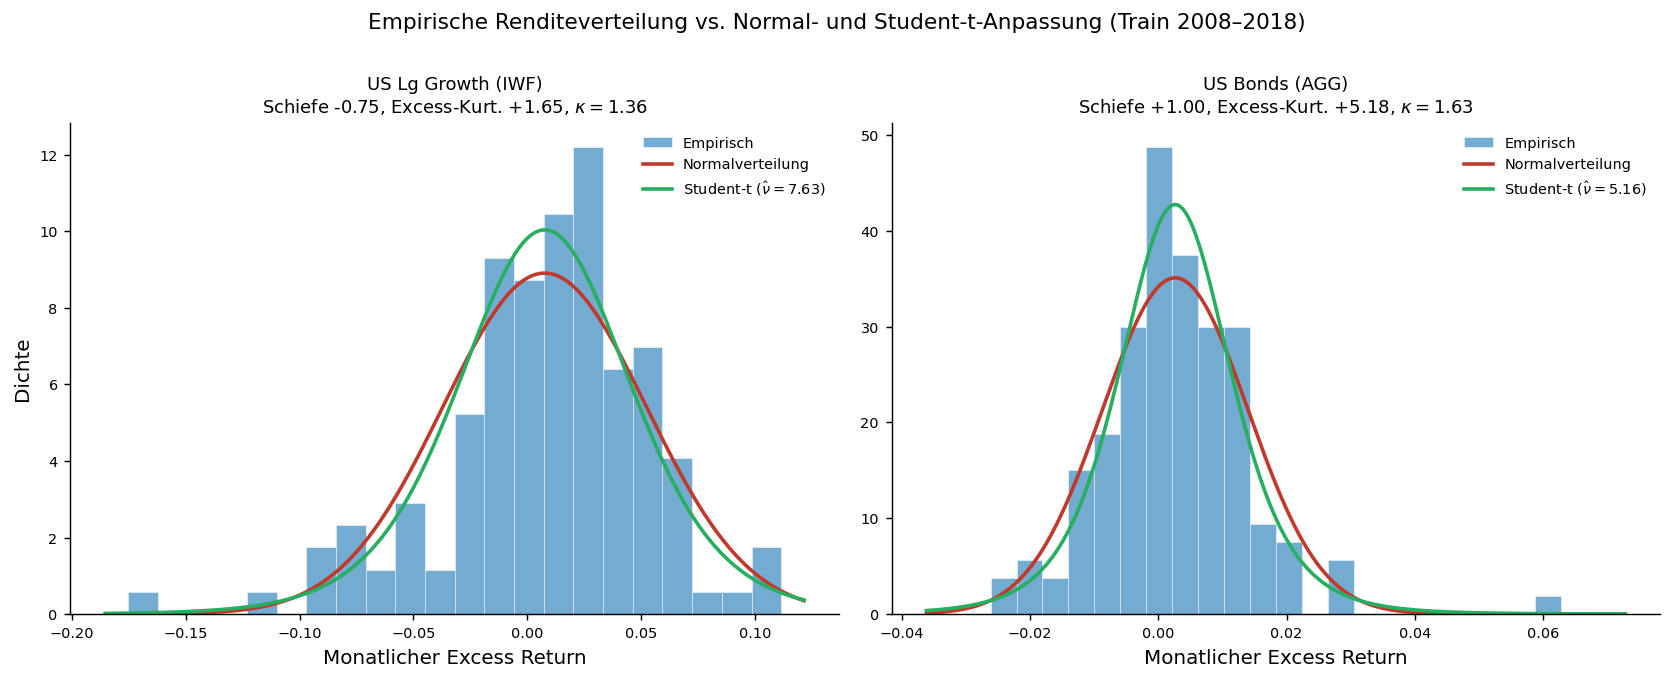

In [10]:
# Abb. (§5.2): Dichte-Vergleich empirisch vs. Normal vs. Student-t (dist_density_fit.png)
from scipy import stats as _st

_TICK = ["AGG","BWX","IWF","IWD","IWO","IWN","EFA","EEM"]
_LAB  = {"AGG":"US Bonds","BWX":"Intl Bonds","IWF":"US Lg Growth","IWD":"US Lg Value",
         "IWO":"US Sm Growth","IWN":"US Sm Value","EFA":"Intl Dev","EEM":"Emg Mkts"}
_ret = pd.read_csv(DATA / "etf_returns_monthly.csv", index_col=0, parse_dates=True)
_rf  = pd.read_csv(DATA / "rf_monthly.csv", index_col=0, parse_dates=True).iloc[:,0]
for _d in (_ret, ):
    _d.index = pd.to_datetime(_d.index).to_period("M").to_timestamp("M")
_rf.index = pd.to_datetime(_rf.index).to_period("M").to_timestamp("M")
_trm = (_ret.index >= "2008-01-01") & (_ret.index <= "2018-12-31")
_exc = _ret[_TICK].loc[_trm].sub(_rf.reindex(_ret.index).ffill().loc[_trm], axis=0)

SEL = ["IWF","AGG"]   # repräsentatives Aktien-ETF und stärkste Tails (kleinstes nu = AGG)
C_HIST, C_NORM, C_T = "#2980b9", "#c0392b", "#27ae60"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, t in zip(axes, SEL):
    r  = _exc[t].dropna().values
    mu, sd = r.mean(), r.std(ddof=1)
    sk, ke = _st.skew(r), _st.kurtosis(r)                  # excess kurtosis
    nu = float(np.clip(4 + 6/ke if ke > 0.01 else 30, 4.1, 30))  # Method-of-Moments (wie Thesis)
    kappa = nu / (nu - 2)
    scale = sd * np.sqrt((nu - 2) / nu)   # Student-t mit gleicher Varianz -> isoliert die Tail-Form
    ax.hist(r, bins=22, density=True, color=C_HIST, alpha=0.65, edgecolor="white", lw=0.4, label="Empirisch")
    xs = np.linspace(r.min() - 0.01, r.max() + 0.01, 400)
    ax.plot(xs, _st.norm.pdf(xs, mu, sd), color=C_NORM, lw=2.0, label="Normalverteilung")
    ax.plot(xs, _st.t.pdf(xs, df=nu, loc=mu, scale=scale), color=C_T, lw=2.0, label=fr"Student-t ($\hat\nu={nu:.2f}$)")
    ax.set_title(f"{_LAB[t]} ({t})\nSchiefe {sk:+.2f}, Excess-Kurt. {ke:+.2f}, $\\kappa={kappa:.2f}$", fontsize=10)
    ax.set_xlabel("Monatlicher Excess Return"); ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("Dichte")
fig.suptitle("Empirische Renditeverteilung vs. Normal- und Student-t-Anpassung (Train 2008\u20132018)", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

Performance (Test Jan 2019 - Dez 2024):
                             Ann. Return  Ann. Volatility  Sharpe Ratio  \
Portfolio                                                                 
CAPM Baseline                      3.847           12.163         0.316   
BLM (Normal)                      17.782           24.393         0.729   
BLM (Normal, Long-Only)            8.368           14.821         0.565   
BLM (Student-t, nu=8.0)           13.241           19.346         0.684   
BLM (t nu=8.0, Long-Only)          6.629           13.289         0.499   
BLM (Student-t, min nu=5.2)       10.700           16.661         0.642   
BLM (t nu=5.2, Long-Only)          5.655           12.469         0.454   

                             Max Drawdown  Total Return  
Portfolio                                                
CAPM Baseline                     -24.784        20.514  
BLM (Normal)                      -51.298       142.625  
BLM (Normal, Long-Only)           -27.870        54.

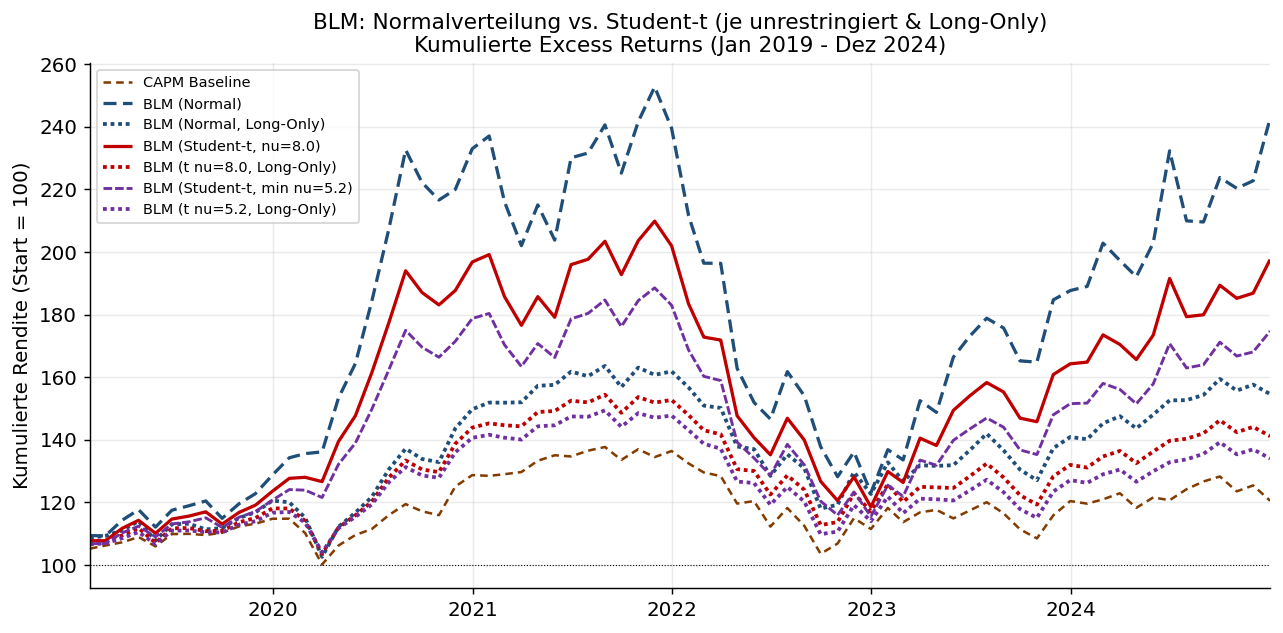

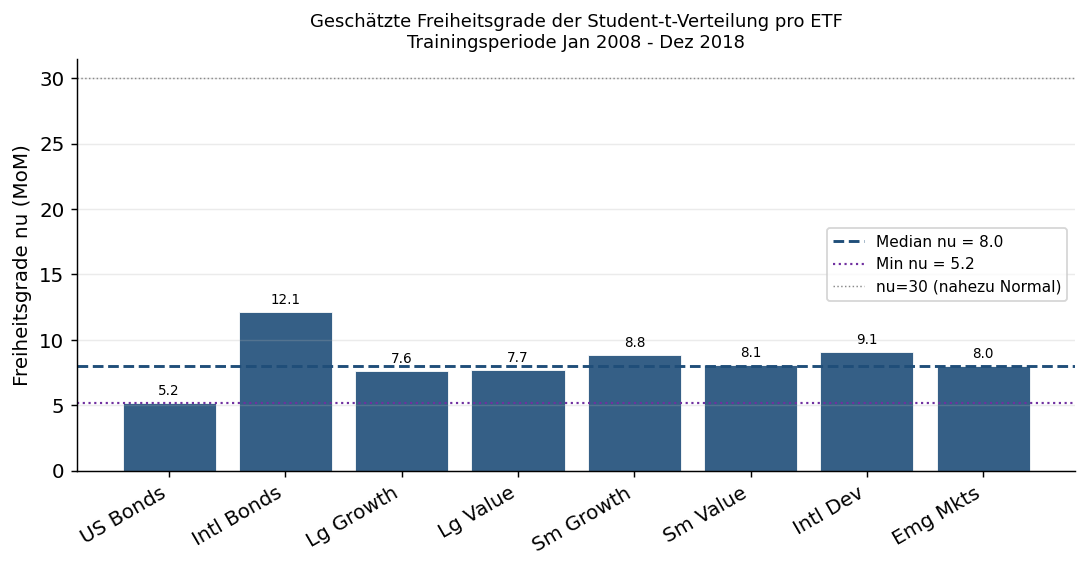

In [11]:
# Backtest
exc_test      = returns_test.sub(rf_test, axis=0)
ret_capm_d    = (exc_test * w_eq).sum(axis=1).rename("CAPM Baseline")
ret_bl_n      = (exc_test * w_BL_normal).sum(axis=1).rename("BLM (Normal)")
ret_bl_t_med  = (exc_test * w_BL_t_med).sum(axis=1).rename(f"BLM (Student-t, nu={nu_median:.1f})")
ret_bl_t_min  = (exc_test * w_BL_t_min).sum(axis=1).rename(f"BLM (Student-t, min nu={nu_min:.1f})")

# Long-Only-Pendants (echte QP, w≥0 & Σw=1; gleiche Zielfunktion auf μ_BL, Σ_post)
from optimize import mv_weights
w_BL_n_lo     = mv_weights(res_normal["mu_BL"], res_normal["Sigma_post"], delta, long_only=True)
w_BL_tmed_lo  = mv_weights(res_t_med["mu_BL"],  res_t_med["Sigma_post"],  delta, long_only=True)
w_BL_tmin_lo  = mv_weights(res_t_min["mu_BL"],  res_t_min["Sigma_post"],  delta, long_only=True)
ret_bl_n_lo     = (exc_test * w_BL_n_lo).sum(axis=1).rename("BLM (Normal, Long-Only)")
ret_bl_tmed_lo  = (exc_test * w_BL_tmed_lo).sum(axis=1).rename(f"BLM (t nu={nu_median:.1f}, Long-Only)")
ret_bl_tmin_lo  = (exc_test * w_BL_tmin_lo).sum(axis=1).rename(f"BLM (t nu={nu_min:.1f}, Long-Only)")

portfolios_d = {"CAPM Baseline": ret_capm_d,
                "BLM (Normal)": ret_bl_n, "BLM (Normal, Long-Only)": ret_bl_n_lo,
                f"BLM (Student-t, nu={nu_median:.1f})": ret_bl_t_med,
                f"BLM (t nu={nu_median:.1f}, Long-Only)": ret_bl_tmed_lo,
                f"BLM (Student-t, min nu={nu_min:.1f})": ret_bl_t_min,
                f"BLM (t nu={nu_min:.1f}, Long-Only)": ret_bl_tmin_lo}
perf_d = performance_summary(portfolios_d, frequency=12)
pp_d   = perf_d.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown", "Total Return"]:
    if col in pp_d.columns: pp_d[col] *= 100
print("Performance (Test Jan 2019 - Dez 2024):"); print(pp_d.round(3))

# Plot 1: Kumulierte Renditen (Paare: gleiche Farbe, Long-Only gepunktet)
PCOLS_D = {
    "CAPM Baseline":                          (C[4], (3,2), 1.4),
    "BLM (Normal)":                           (C[0], (4,2), 1.8),
    "BLM (Normal, Long-Only)":                (C[0], (1,1), 2.1),
    f"BLM (Student-t, nu={nu_median:.1f})":   (C[1], (1,0), 1.8),
    f"BLM (t nu={nu_median:.1f}, Long-Only)": (C[1], (1,1), 2.1),
    f"BLM (Student-t, min nu={nu_min:.1f})":  (C[3], (3,1), 1.6),
    f"BLM (t nu={nu_min:.1f}, Long-Only)":    (C[3], (1,1), 2.1),
}
fig, ax = plt.subplots(figsize=(10, 5))
for name, ret in portfolios_d.items():
    col, dsh, lw = PCOLS_D[name]
    cr = cumulative_returns(ret) * 100
    ax.plot(cr.index, cr.values, label=name, color=col, dashes=dsh, lw=lw)
ax.axhline(100, color="black", lw=0.6, ls=":")
ax.set_title("BLM: Normalverteilung vs. Student-t (je unrestringiert & Long-Only)\nKumulierte Excess Returns (Jan 2019 - Dez 2024)")
ax.set_ylabel("Kumulierte Rendite (Start = 100)")
ax.set_xlim(returns_test.index[0], returns_test.index[-1])
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)

# Plot 2: nu-Schätzungen pro ETF
nu_vals_list = [float(nu_df.loc[t, "nu (MoM)"]) for t in assets]
short_labels = [SHORT[t] for t in assets]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(range(len(assets)), nu_vals_list, color=C[0], edgecolor="white", linewidth=0.5, alpha=0.9)
ax.axhline(nu_median, color=C[0], lw=1.6, ls="--", label=f"Median nu = {nu_median:.1f}")
ax.axhline(nu_min,    color=C[3], lw=1.2, ls=":",  label=f"Min nu = {nu_min:.1f}")
ax.axhline(30,        color="#888888", lw=0.8, ls=":", label="nu=30 (nahezu Normal)")
for i, v in enumerate(nu_vals_list):
    ax.text(i, v+0.4, f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(range(len(assets))); ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel("Freiheitsgrade nu (MoM)")
ax.set_title("Geschätzte Freiheitsgrade der Student-t-Verteilung pro ETF\nTrainingsperiode Jan 2008 - Dez 2018", fontsize=10)
ax.legend(fontsize=8.5); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)


---
## §5.3 · Risk Budgeting: MV | BLM | Risk Parity | RBMV | BLM-RBMV

In [12]:
# BLM-Gewichte berechnen
Sigma_sc  = sample_cov(excess_train, annualize=True, frequency="M")
Sigma_np  = Sigma_sc.values
mu_sample = excess_train.mean().values * 12  # annualisiert

views_rb = ViewSet(asset_names=assets)
views_rb.add_relative(["IWF"], ["IWD"], expected_diff=0.03, confidence=0.50, label="US Growth > US Value (IWF>IWD): +3% p.a.")
views_rb.add_relative(["EEM"], ["EFA"], expected_diff=0.04, confidence=0.50, label="Emerg. Mkt. > Intl. Dev. (EEM>EFA): +4% p.a.")
views_rb.add_relative(["IWF"], ["AGG"], expected_diff=0.06, confidence=0.50, label="US Growth > US Bonds (IWF>AGG): +6% p.a.")

P, Q, Omega = views_rb.build(Sigma=Sigma_sc, tau=TAU, omega_method="idzorek")
res_blm_rb  = run_blm(Sigma_sc, w_eq, P, Q, Omega, delta=delta, tau=TAU)
mu_BL       = res_blm_rb["mu_BL"].values
pi_rb       = res_blm_rb["pi"].values
w_BL_rb     = res_blm_rb["w_BL"]

# Long-Only-BLM: echte QP (w≥0 & Σw=1) statt clip+renormieren (core/optimize).
# Konsistent mit den übrigen Long-only-Strategien (MV, RBMV) in diesem Vergleich.
from optimize import mv_weights
w_BL_pos = np.asarray(mv_weights(res_blm_rb["mu_BL"], res_blm_rb["Sigma_post"], delta, long_only=True))

# RBMV-Parameter
d = len(assets)
b = np.ones(d) / d  # Risk-Parity Budget

mu_min_sample, sigma_max = auto_params(Sigma_np, mu_sample, sigma_buffer=0.02, sigma_cap=0.25, mu_discount=0.80)
mu_min_blm, _            = auto_params(Sigma_np, mu_BL,     sigma_buffer=0.02, sigma_cap=0.25, mu_discount=0.80)

print(f"RBMV-Parameter (Sample-mu):  mu_min={mu_min_sample:.4f}, sigma_max={sigma_max:.4f}")
print(f"RBMV-Parameter (BLM-mu):     mu_min={mu_min_blm:.4f},   sigma_max={sigma_max:.4f}")

# Portfoliogewichte
print("\nBerechne Portfoliogewichte ...")
w_capm     = w_eq.values.copy()
w_mv       = solve_mv(Sigma_np, mu_sample, mu_min_sample, sigma_max)
w_rp       = solve_rb(b, Sigma_np)
w_rbmv     = solve_rbmv(b, Sigma_np, mu_sample, mu_min_sample, sigma_max)
w_blm_rb   = w_BL_pos
w_blm_rbmv = solve_rbmv(b, Sigma_np, mu_BL, mu_min_blm, sigma_max)
weights_tab = pd.DataFrame({
    "CAPM Baseline": w_capm, "MV": w_mv, "Risk Parity": w_rp,
    "RBMV": w_rbmv, "BLM": w_blm_rb, "BLM-RBMV": w_blm_rbmv,
}, index=assets) * 100.0
print("\nPortfoliogewichte (%):")
print(weights_tab.round(2).to_string())


RBMV-Parameter (Sample-mu):  mu_min=0.0411, sigma_max=0.0583
RBMV-Parameter (BLM-mu):     mu_min=0.0162,   sigma_max=0.0583

Berechne Portfoliogewichte ...

Portfoliogewichte (%):
     CAPM Baseline     MV  Risk Parity   RBMV    BLM  BLM-RBMV
AGG          19.34  84.11        51.49  65.29  16.10     63.40
BWX          26.13   0.00        14.59   6.93   2.36     11.09
IWF          12.09  15.89         6.65   8.22  39.80      5.10
IWD          12.09   0.00         6.57   5.01   0.00      5.02
IWO           1.34   0.00         5.48   5.14   0.00      4.19
IWN           1.34   0.00         5.65   4.55   0.00      4.30
EFA          24.18   0.00         5.15   2.60   0.00      3.73
EEM           3.49   0.00         4.42   2.25  41.74      3.16


Performance (Test Jan 2019 - Dez 2024):
               Ann. Return  Ann. Volatility  Sharpe Ratio  Max Drawdown  Total Return
Portfolio                                                                            
CAPM Baseline         3.85            12.16          0.32        -24.78         20.51
MV                    2.00             7.40          0.27        -19.87         10.93
Risk Parity           2.11             9.65          0.22        -22.45         10.41
RBMV                  2.11             8.73          0.24        -21.53         10.95
BLM                   8.37            14.82          0.56        -27.87         54.60
BLM-RBMV              1.31             8.55          0.15        -22.14          5.84


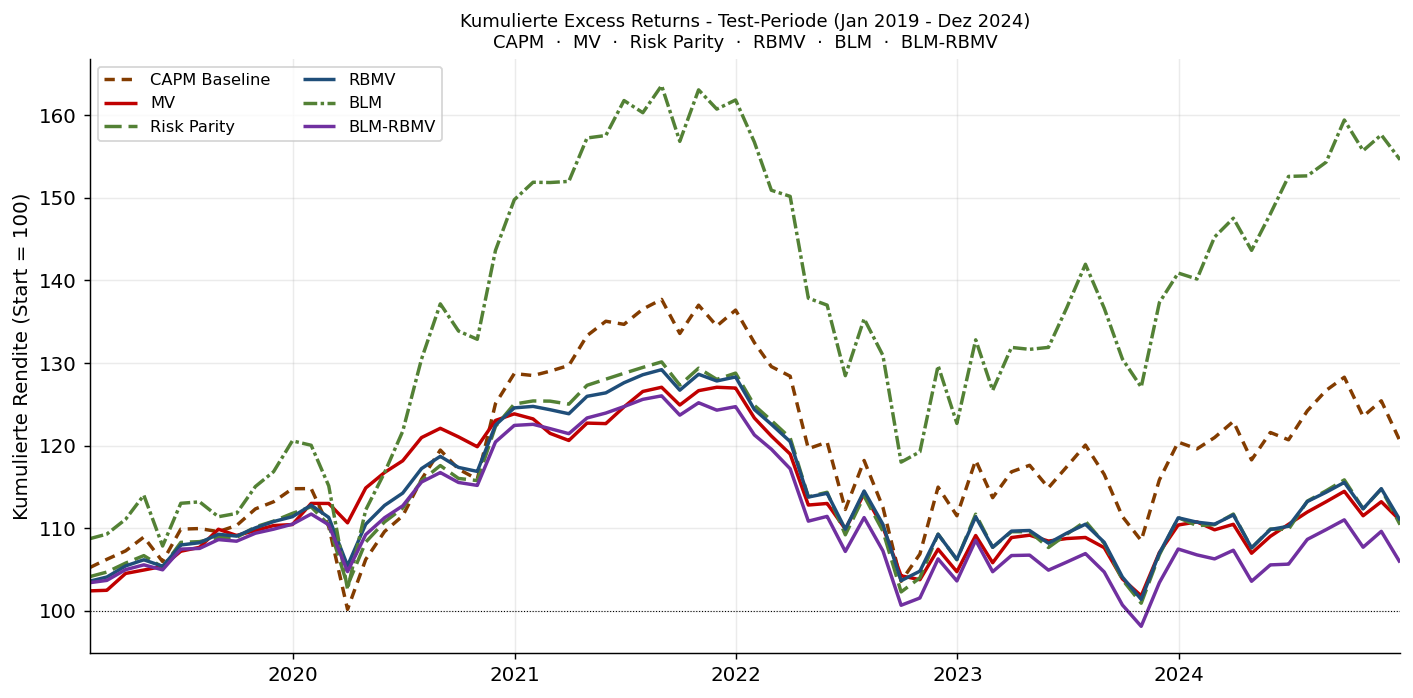

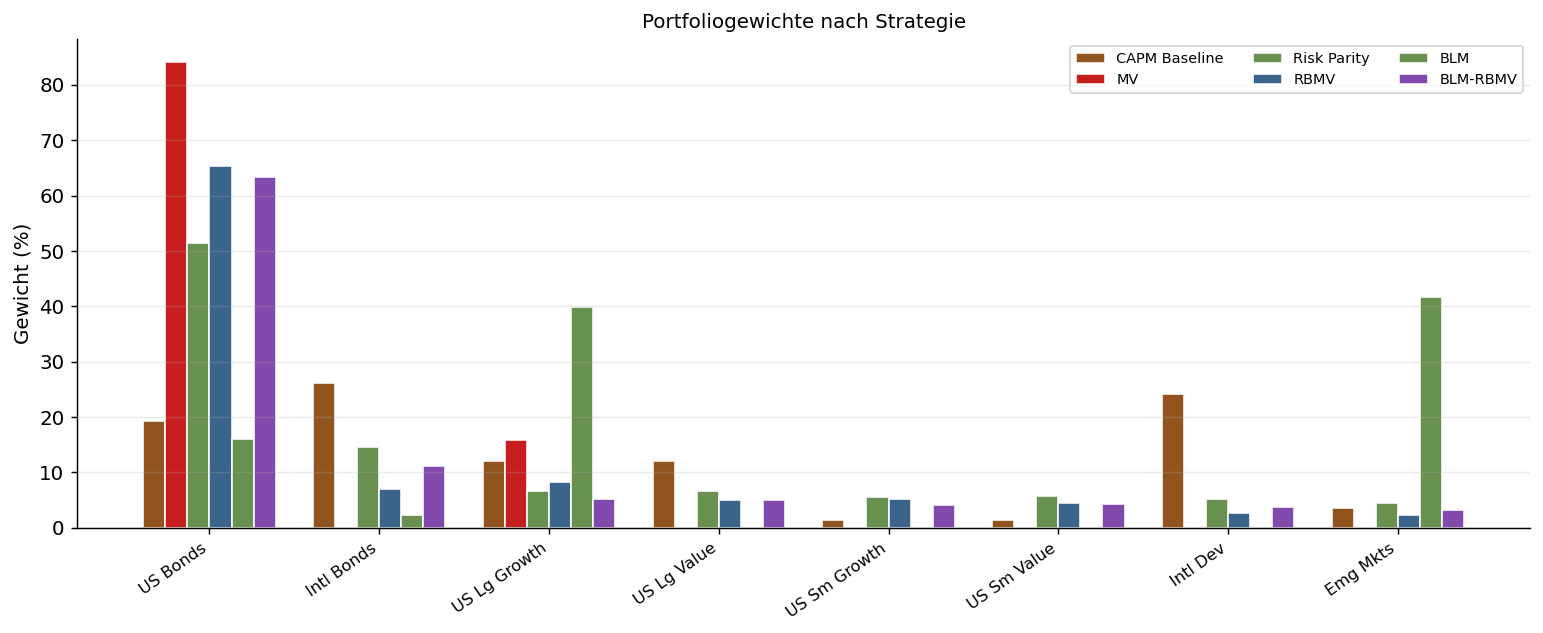

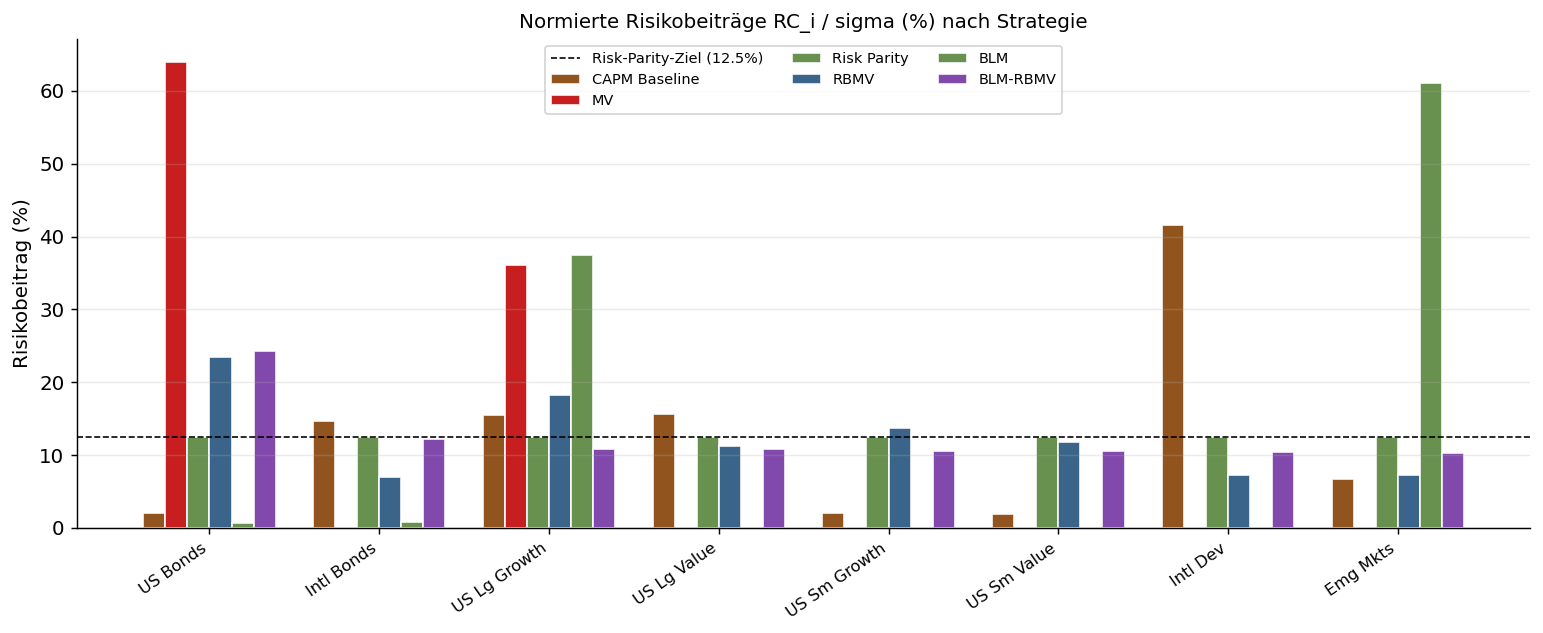

In [13]:
# Backtest
weights_dict = {"CAPM Baseline": w_capm, "MV": w_mv, "Risk Parity": w_rp,
                "RBMV": w_rbmv, "BLM": w_blm_rb, "BLM-RBMV": w_blm_rbmv}
PALETTE = {"CAPM Baseline": C[4], "MV": C[1], "Risk Parity": C[2],
           "RBMV": C[0], "BLM": C[2], "BLM-RBMV": C[3]}
DASHES  = {"CAPM Baseline": (3,2), "MV": (1,0), "Risk Parity": (5,2),
           "RBMV": (1,0), "BLM": (4,1,1,1), "BLM-RBMV": (1,0)}

exc_test_rb = returns_test.sub(rf_test, axis=0)
portfolios_rb = {}
for name, w in weights_dict.items():
    w_s = pd.Series(w, index=assets)
    portfolios_rb[name] = (exc_test_rb * w_s).sum(axis=1).rename(name)

perf_rb = performance_summary(portfolios_rb, frequency=12)
pp_rb   = perf_rb.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown", "Total Return"]:
    if col in pp_rb.columns: pp_rb[col] *= 100
print("Performance (Test Jan 2019 - Dez 2024):"); print(pp_rb.round(2).to_string())

# Plot 1: Kumulierte Renditen
fig, ax = plt.subplots(figsize=(11, 5.5))
for name, ret in portfolios_rb.items():
    cr = cumulative_returns(ret) * 100
    ax.plot(cr.index, cr.values, label=name, color=PALETTE[name], dashes=DASHES[name], lw=1.9)
ax.axhline(100, color="black", lw=0.6, ls=":")
ax.set_title("Kumulierte Excess Returns - Test-Periode (Jan 2019 - Dez 2024)\nCAPM  ·  MV  ·  Risk Parity  ·  RBMV  ·  BLM  ·  BLM-RBMV", fontsize=10)
ax.set_ylabel("Kumulierte Rendite (Start = 100)")
ax.set_xlim(returns_test.index[0], returns_test.index[-1])
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)

# Plot 2: Portfoliogewichte
strategies = list(weights_dict.keys())
n_strat    = len(strategies)
x          = np.arange(d)
bar_w      = 0.13
offsets    = np.linspace(-(n_strat-1)/2, (n_strat-1)/2, n_strat) * bar_w

fig, ax = plt.subplots(figsize=(12, 5))
for j, (name, w) in enumerate(weights_dict.items()):
    ax.bar(x + offsets[j], w * 100, bar_w, label=name, color=PALETTE[name], alpha=0.88, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([LABELS[t] for t in assets], rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Portfoliogewichte nach Strategie", fontsize=11); ax.set_ylabel("Gewicht (%)")
ax.legend(fontsize=8, ncol=3); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)

# Plot 3: Risikobeiträge
rc_dict = {}
for name, w in weights_dict.items():
    rc = risk_contributions(w, Sigma_np)
    rc_dict[name] = rc / rc.sum() * 100 if rc.sum() > 1e-12 else rc

fig, ax = plt.subplots(figsize=(12, 5))
for j, (name, rc_n) in enumerate(rc_dict.items()):
    ax.bar(x + offsets[j], rc_n, bar_w, label=name, color=PALETTE[name], alpha=0.88, edgecolor="white")
ax.axhline(100/d, color="black", lw=0.9, ls="--", label=f"Risk-Parity-Ziel ({100/d:.1f}%)")
ax.set_xticks(x); ax.set_xticklabels([LABELS[t] for t in assets], rotation=35, ha="right", fontsize=9)
ax.set_title("Normierte Risikobeiträge RC_i / sigma (%) nach Strategie", fontsize=11); ax.set_ylabel("Risikobeitrag (%)")
ax.legend(fontsize=8, ncol=3); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); display(fig); plt.close(fig)
